## Load your data (for public sharing)

In [22]:
import gdown
import pandas as pd

# 명진님의 파일 ID로 설정됨
file_id = '1vFZmn-8XZzZl9b2Y9z5UbdjAXZHMO7aE'

# 코랩 환경에 저장될 파일 이름
output_filename = 'filtered_reddit_data.xlsx'

# 구글 드라이브에서 다운로드 (직접 다운로드 링크 생성)
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, output_filename, quiet=False)

print(f"File '{output_filename}' downloaded successfully!")

# 엑셀 파일이므로 read_excel 사용
df_raw = pd.read_excel(output_filename)

# 데이터 상위 5개 행 확인
display(df_raw.head())

Downloading...
From: https://drive.google.com/uc?id=1vFZmn-8XZzZl9b2Y9z5UbdjAXZHMO7aE
To: /content/filtered_reddit_data.xlsx
100%|██████████| 10.4M/10.4M [00:00<00:00, 58.1MB/s]


File 'filtered_reddit_data.xlsx' downloaded successfully!


,comment_id,score,self_text,subreddit,created_time,post_id,author_name,controversiality,ups,downs,...,user_link_karma,user_comment_karma,user_total_karma,post_score,post_self_text,post_title,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time
0,k857c4c,3,Would you be able to post links to the indepen...,IsraelPalestine,2023-11-06 23:59:00,17p73rm,Alive_Collection_454,0,3,0,...,20,924,944,62,My buddy and I were discussing over the situat...,Is Hamas lying when releasing numbers of fatal...,0.74,62,0,2023-11-06 16:50:00
1,k857b4l,13,Of course it's important. Until the 20th centu...,IsraelPalestine,2023-11-06 23:59:00,17pdtfd,kawaii_war_dandy,0,13,0,...,685,8579,9264,57,I just read in the [New York Times](https://ww...,How does the Al Shifa hospital house 60 000 pe...,0.85,57,0,2023-11-06 21:36:00
2,k857amm,1,"ISW, the conservative think tank representing ...",IsraelPalestine,2023-11-06 23:59:00,17p76sb,Having_A_Day,0,1,0,...,3,3052,3055,31,Now that the IDF has boots on the ground in Ga...,Public Reaction to Ground Footage,0.82,31,0,2023-11-06 16:54:00
3,k8579mi,1,###[View link](https://rapidsave.com/info?url=...,NonCredibleDefense,2023-11-06 23:59:00,17obtsm,SaveVideo,0,1,0,...,15073,641575,656648,1433,NaN,Hamas Air Support in a nutshell,0.96,1433,0,2023-11-05 13:21:00
4,k8578wh,14,I find it extremely unlikely that these specia...,CombatFootage,2023-11-06 23:59:00,17p7mfx,what-the-puck,0,14,0,...,1095,166322,169946,11536,NaN,Better footage of the israeli special forces a...,0.94,11536,0,2023-11-06 17:12:00


In [23]:
import string
import re

def clean_text(text):
  text = str(text)

  # Step 1: Lowercase
  text = text.lower()

  # Step 2: Use remove_punct to remove punctuation marks
  text = text.translate(str.maketrans('', '', string.punctuation))

  # Step 3: Remove URL
  text = re.sub(r'http\S+', '', text)

  # Step 4: Remove extra whitespace characters
  text = " ".join(text.split())

  return text.strip()

In [24]:
# Apply the cleaning function to your text column of the DataFrame
text_column = 'self_text'
clean_text_column = 'cleaned_text'

df_raw[clean_text_column] = df_raw[text_column].apply(
    lambda x: clean_text(x)
)

display(df_raw[[text_column, clean_text_column]].head())


,self_text,cleaned_text
0,Would you be able to post links to the indepen...,would you be able to post links to the indepen...
1,Of course it's important. Until the 20th centu...,of course its important until the 20th century...
2,"ISW, the conservative think tank representing ...",isw the conservative think tank representing u...
3,###[View link](https://rapidsave.com/info?url=...,view link info feedback for savevideoamp32amp3...
4,I find it extremely unlikely that these specia...,i find it extremely unlikely that these specia...


In [25]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# 불용어 데이터셋 다운로드
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words('english')) # 영어 기준

# 10~20개 예시 추출 (앞부분 일부 사용)
examples = df_raw['cleaned_text'].head(15).tolist()

for i, text in enumerate(examples):
    tokens = word_tokenize(text) # 토큰화 (단어 단위로 쪼개기)
    filtered_text = [w for w in tokens if not w in stop_words] # 불용어 제외

    print(f"[{i+1}] 원본: {text[:100]}...")
    print(f"[{i+1}] 제거 후: {' '.join(filtered_text)[:100]}...")
    print("-" * 120)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


[1] 원본: would you be able to post links to the independent agencies confirming not merely restating not kidd...
[1] 제거 후: would able post links independent agencies confirming merely restating kidding im genuinely interest...
------------------------------------------------------------------------------------------------------------------------
[2] 원본: of course its important until the 20th century bad hygiene and diseases killed more people than actu...
[2] 제거 후: course important 20th century bad hygiene diseases killed people actual war violance...
------------------------------------------------------------------------------------------------------------------------
[3] 원본: isw the conservative think tank representing us defense contractors...
[3] 제거 후: isw conservative think tank representing us defense contractors...
------------------------------------------------------------------------------------------------------------------------
[4] 원본: view link info feedback for savevideo

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Q1: TF-IDF and Important Words per Document

- 1.1 Build a TF-IDF matrix
    - Use `TfidfVectorizer` from `sklearn` to vectorize your cleaned text column. Try different parameter settings (e.g., different `min_df`, `max_df`, `stop_words`, `ngram_range`) and choose the most appropriate one.

- 1.2 Group-level TF-IDF
    - Pick a categorical variable in your data (e.g., sentiment, source, year, topic label). Compute the **mean TF-IDF score per token within each group**, and plot the top 10 tokens for at least 2 groups side by side. You can visualize the top tokens using a bar chart of token vs. score works well or a wordcloud.

- 1.3 Reflection (3-5 sentences)
    - Did TF-IDF words look meaningful, or mostly noise (rare typos, proper nouns, etc.)?
    - How did changing parameters in 1.1 affect the results?
    - For your dataset, is TF-IDF a useful starting point, or does it miss something important?

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

# ── 데이터 로드 ────────────────────────────────────────────────
df_raw = pd.read_excel('filtered_reddit_data.xlsx')
df_raw['self_text'] = df_raw['self_text'].astype(str).fillna('')
df_raw = df_raw[(df_raw['self_text'].str.strip() != '') & (df_raw['self_text'] != 'nan')]
df_raw = df_raw.reset_index(drop=True)

clean_text_column = 'self_text'   # 텍스트 열 이름
group_column      = 'subreddit'   # 그룹 기준 열


# ── 1.1 Build TF-IDF matrices with different settings ─────────

# 기본 세팅 (단어 1개 단위)
vec_basic = TfidfVectorizer(stop_words='english', min_df=5)
tfidf_basic = vec_basic.fit_transform(df_raw[clean_text_column])

# 설정 1: 보수적인 세팅 (단어 1개씩, 엄격한 필터링)
vec_setting1 = TfidfVectorizer(stop_words='english', min_df=15, max_df=0.6, ngram_range=(1, 1))
tfidf1 = vec_setting1.fit_transform(df_raw[clean_text_column])

# 설정 2: 문맥 중심 세팅 (단어 1~2개 조합, 부드러운 필터링) → 최종 선택
best_vectorizer = TfidfVectorizer(stop_words='english', min_df=10, max_df=0.7, ngram_range=(1, 2))
tfidf2 = best_vectorizer.fit_transform(df_raw[clean_text_column])

# 설정 3: 더 긴 문맥 세팅 (단어 1~3개 조합, 필터링 완화)
vec_setting3 = TfidfVectorizer(stop_words='english', min_df=5, max_df=0.8, ngram_range=(1, 3))
tfidf3 = vec_setting3.fit_transform(df_raw[clean_text_column])

print(f"기본 세팅 단어 사전 크기: {tfidf_basic.shape[1]}개")
print(f" [설정 1] 단어 사전 크기: {tfidf1.shape[1]}개")
print(f" [설정 2] 단어 사전 크기: {tfidf2.shape[1]}개")
print(f" [설정 3] 단어 사전 크기: {tfidf3.shape[1]}개")

기본 세팅 단어 사전 크기: 10132개
 [설정 1] 단어 사전 크기: 4777개
 [설정 2] 단어 사전 크기: 9424개
 [설정 3] 단어 사전 크기: 21107개



[IsraelPalestine] 상위 10 토큰:
   1. israel                         0.0373
   2. hamas                          0.0348
   3. gaza                           0.0201
   4. people                         0.0193
   5. war                            0.0166
   6. palestinians                   0.0166
   7. jews                           0.0164
   8. don                            0.0159
   9. just                           0.0135
  10. think                          0.0134

[NonCredibleDefense] 상위 10 토큰:
   1. just                           0.0148
   2. like                           0.0142
   3. hamas                          0.0125
   4. israel                         0.0109
   5. https                          0.0095
   6. people                         0.0084
   7. don                            0.0080
   8. time                           0.0074
   9. know                           0.0073
  10. gt                             0.0071

[CombatFootage] 상위 10 토큰:
   1. hamas                     

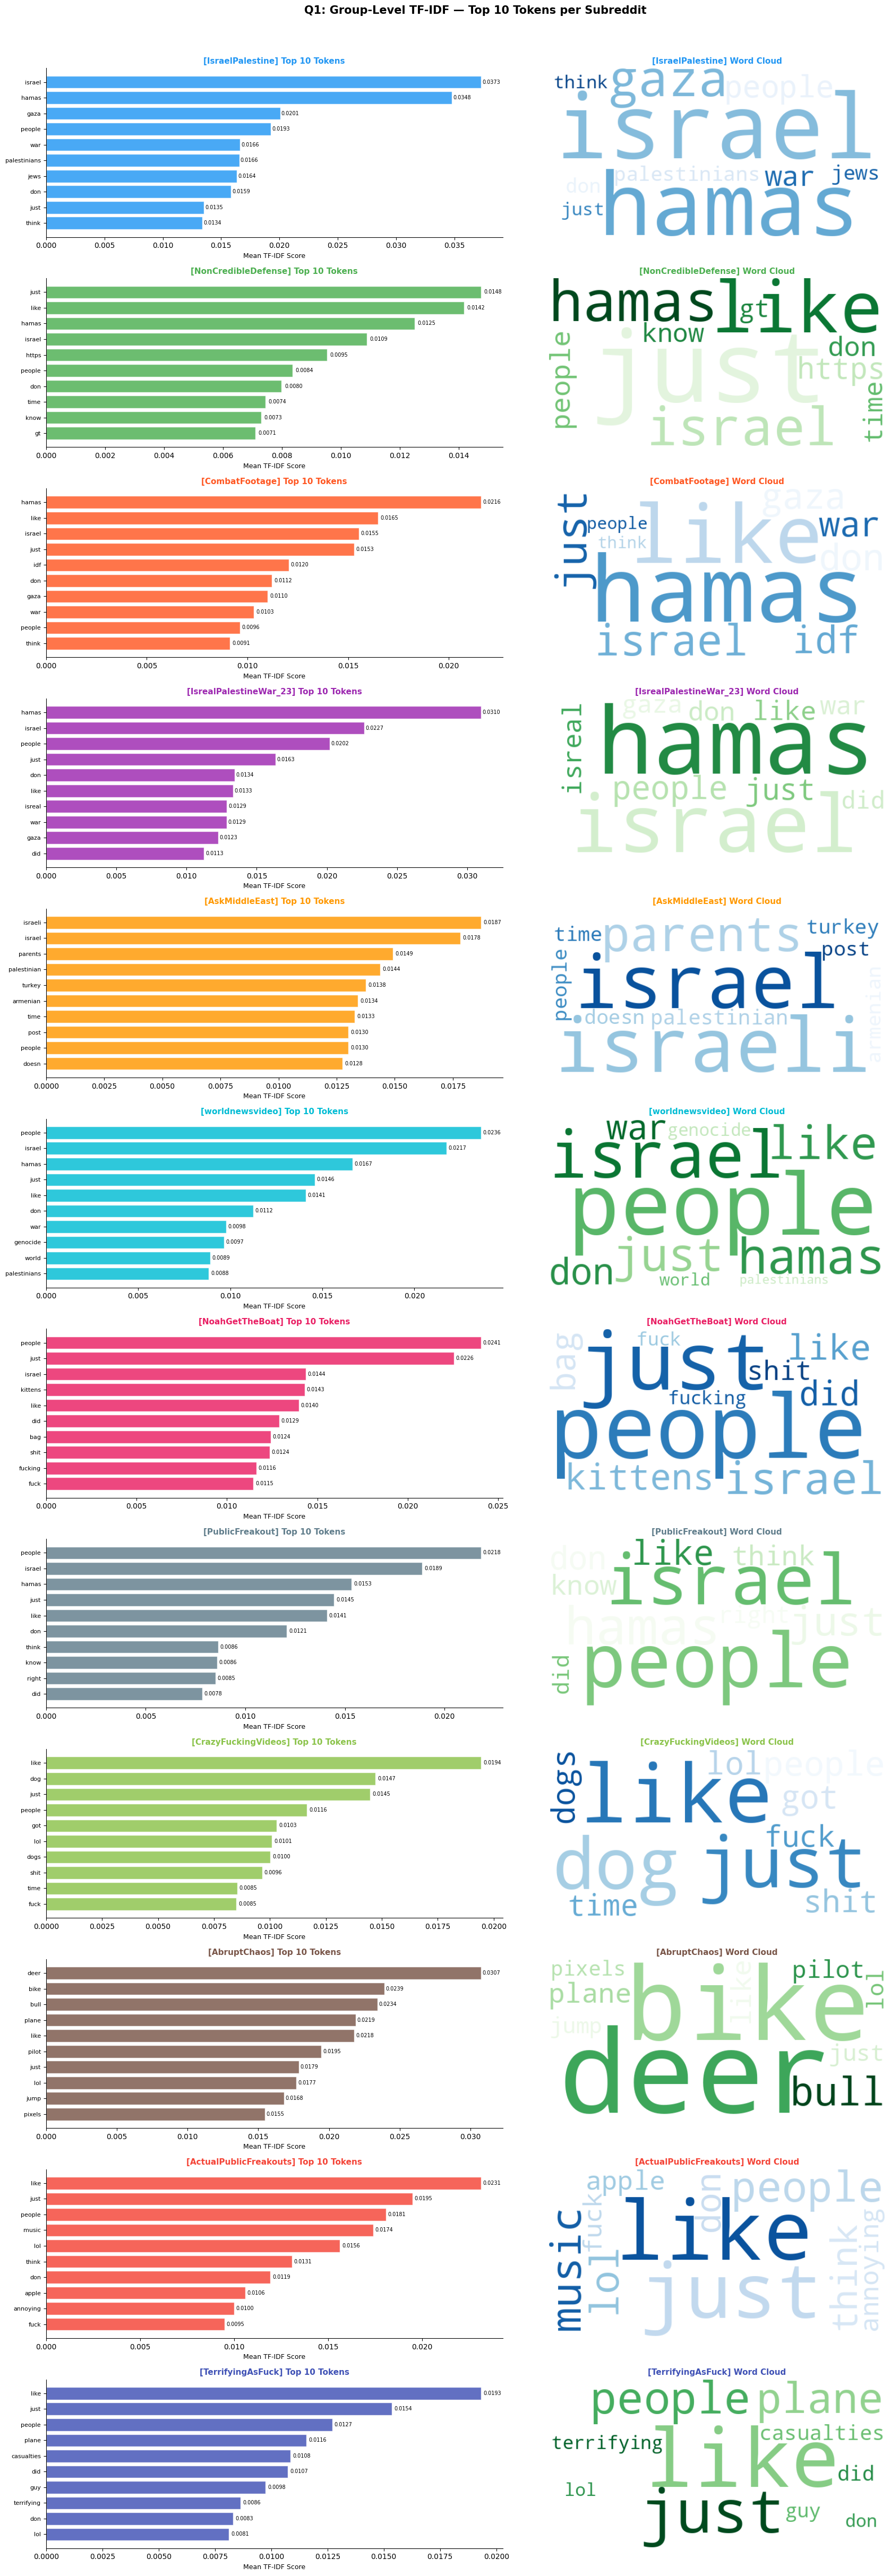


시각화 저장 완료: q1_tfidf_analysis.png


In [34]:
# 1.2 Group-level TF-IDF
feature_names = best_vectorizer.get_feature_names_out()
groups        = df_raw[group_column].unique().tolist()

# 그룹별 평균 TF-IDF 점수 계산 → 상위 10개 토큰 추출
group_top_tokens = {}
for group in groups:
    idx        = df_raw[df_raw[group_column] == group].index
    subset     = tfidf2[idx]
    avg_scores = np.asarray(subset.mean(axis=0)).flatten()
    top10_idx  = avg_scores.argsort()[::-1][:10]
    group_top_tokens[group] = [(feature_names[i], avg_scores[i]) for i in top10_idx]

# 결과 출력
for group, tokens in group_top_tokens.items():
    print(f"\n[{group}] 상위 10 토큰:")
    for rank, (token, score) in enumerate(tokens, 1):
        print(f"  {rank:2d}. {token:<30s} {score:.4f}")

# ── 시각화: 막대 차트 + 워드클라우드 ─────────────────────────
n      = len(groups)
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0',
          '#FF9800', '#00BCD4', '#E91E63', '#607D8B',
          '#8BC34A', '#795548', '#F44336', '#3F51B5']

fig, axes = plt.subplots(n, 2, figsize=(18, n * 4))
fig.suptitle('Q1: Group-Level TF-IDF — Top 10 Tokens per Subreddit',
             fontsize=15, fontweight='bold', y=1.01)

for i, group in enumerate(groups):
    tokens = [t for t, _ in group_top_tokens[group]]
    scores = [s for _, s in group_top_tokens[group]]
    color  = colors[i % len(colors)]

    # 막대 차트
    ax_bar = axes[i][0]
    bars   = ax_bar.barh(tokens[::-1], scores[::-1], color=color, alpha=0.82, edgecolor='white')
    ax_bar.set_title(f'[{group}] Top 10 Tokens', fontsize=11, fontweight='bold', color=color)
    ax_bar.set_xlabel('Mean TF-IDF Score', fontsize=9)
    ax_bar.tick_params(axis='y', labelsize=8)
    for bar, score in zip(bars, scores[::-1]):
        ax_bar.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height() / 2,
                    f'{score:.4f}', va='center', fontsize=7)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)

    # 워드클라우드
    ax_wc     = axes[i][1]
    freq_dict = {t: s for t, s in group_top_tokens[group]}
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap='Blues' if i % 2 == 0 else 'Greens',
                   max_words=50, prefer_horizontal=0.7)
    wc.generate_from_frequencies(freq_dict)
    ax_wc.imshow(wc, interpolation='bilinear')
    ax_wc.axis('off')
    ax_wc.set_title(f'[{group}] Word Cloud', fontsize=11, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('q1_tfidf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n시각화 저장 완료: q1_tfidf_analysis.png")

### 1.3 Reflection

🔵 IsraelPalestine — 가장 깔끔해요. israel, hamas, gaza, jews, palestinians, war → 분쟁 핵심 키워드가 잘 잡혔어요.

🟢 NonCredibleDefense — hamas, israel 외에 https, lgt 같은 URL/링크 잔재가 보여요. 텍스트 전처리가 더 필요한 신호예요.

🟠 CombatFootage — idf (이스라엘 방위군)가 특징적으로 등장해요. 전투 영상 특성상 군사 용어가 나오는 게 맞아요.

🟣 IsrealPalestineWar_23 — isreal (오타)가 보여요. 이 서브레딧 이름 자체가 오타인데 댓글에도 그대로 반영된 거예요.

🟡 AskMiddleEast — armenian, parents, turkey, post → 다른 서브레딧과 확실히 달라요. 이스라엘-팔레스타인 외에 중동 전반 질문이 올라오는 곳이라 그래요.

🔵 worldnewsvideo — 전반적으로 다른 서브레딧과 비슷하고 고유성이 낮아요.

🩷 NoahGetTheBoat — kittens, fuck, shit, fucking → 이 서브레딧은 분위기 자체가 달라요. 밈/유머 성격의 커뮤니티라 욕설과 이상한 단어가 섞여 있어요.

🟢 PublicFreakout / CrazyFuckingVideos — israel이 상위권인데, 이건 2023년 10월 하마스 공격 영상이 이 서브레딧에 많이 퍼졌기 때문이에요.

⚫ AbruptChaos — bike, deer, bull, plane, pilot, pixels → 완전히 다른 주제예요. 갑작스러운 사고/혼돈 영상 서브레딧이라 이스라엘 주제와 무관한 단어들이 나와요.

🔴 ActualPublicFreakouts — music, apple, lol → 역시 일반 영상 서브레딧 성격.

🔵 TerrifyingAsFuck — plane, casualties, terrifying → 공포/재난 영상 특성이 반영됐어요.

Q1. Were the TF-IDF tokens meaningful, or mostly noise?
Mixed results. Tokens like israel, hamas, gaza, idf, palestinians, and casualties meaningfully reflected each subreddit's topic. However, conversational words like just, like, don, people, and think appeared in the top ranks across almost every group, suggesting that the default English stop_words filter is insufficient for Reddit's informal writing style. Additional noise was found in URL remnants like https and typos like isreal, indicating that more thorough text preprocessing would improve results.

** Q2. Is TF-IDF a useful starting point for this dataset, or is it missing something important? **

TF-IDF is a useful starting point, but its limitations are clear. Since more than half of the 12 subreddits share the same Israel-Palestine topic, common tokens like israel and hamas dominate across groups, making it difficult to distinguish subreddit-level characteristics. TF-IDF also ignores word order and context, meaning "Israel attacked Hamas" and "Hamas attacked Israel" are treated identically. To capture sentiment or ideological differences between communities, additional techniques such as sentiment analysis or topic modeling (LDA) would be necessary in later stages.

## Q2: Static Word Embeddings (Word2Vec / GloVe / fastText)


- 2.1 Load a pretrained model
    - **English data**: test multiple pretrained models from `gensim.downloader`: `word2vec-google-news-300`, `glove-wiki-gigaword-300`, `fasttext-wiki-news-subwords-300`.
    - **Korean data**: test Korean fastText (`facebook/fasttext-ko-vectors` from Hugging Face, or download `cc.ko.300.bin` directly). .

- 2.2 Word similarity probe
    - Pick 5-10 words that are meaningful in *your* data (domain-specific terms, named entities, frequent topics, etc.). For each word, print the top 10 most similar words from the embedding model.

- 2.3 Reflection (3-5 sentences)
    - Were the nearest neighbors meaningful for *your* domain, or were they generic?
    - Where did models disagree or where did each model struggle?
    - Pretrained models were trained on news / Wikipedia — does that match your data's domain? What words are you most worried about?


In [4]:
# 2.1 Load pretrained models
!pip install gensim
import gensim.downloader as api
import pandas as pd
import numpy as np

# ── 2.1 Load pretrained models ────────────────────────────────

print("Loading word2vec-google-news-300 ...")
model_w2v = api.load("word2vec-google-news-300")
print("✅ word2vec 로드 완료")

print("Loading glove-wiki-gigaword-300 ...")
model_glove = api.load("glove-wiki-gigaword-300")
print("✅ GloVe 로드 완료")

print("Loading fasttext-wiki-news-subwords-300 ...")
model_ft = api.load("fasttext-wiki-news-subwords-300")
print("✅ fastText 로드 완료")

models = {
    "Word2Vec": model_w2v,
    "GloVe":    model_glove,
    "fastText": model_ft,}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.0 MB/s eta 0:00:00
Loading word2vec-google-news-300 ...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
✅ word2vec 로드 완료
Loading glove-wiki-gigaword-300 ...
[==================================================] 100.0% 376.1/376.1MB downloaded
✅ GloVe 로드 완료
Loading fasttext-wiki-news-subwords-300 ...
[==================================================] 100.0% 958.5/958.4MB downloaded
✅ fastText 로드 완료


In [5]:
# 2.2 Word similarity probe
# 우리 데이터에서 중요한 단어 10개 선택 (Q1 TF-IDF 결과 기반)
models = {
    "Word2Vec": model_w2v,
    "GloVe":    model_glove,
    "fastText": model_ft,
}

probe_words = [
    "israel", "hamas", "gaza", "palestinians",
    "war", "ceasefire", "idf", "terrorism",
    "occupation", "genocide"
]

for word in probe_words:
    print(f"\n{'='*60}")
    print(f"🔍 '{word}' 와 가장 유사한 단어 TOP 10")
    print(f"{'='*60}")

    for model_name, model in models.items():
        print(f"\n  [{model_name}]")
        try:
            similar = model.most_similar(word, topn=10)
            for rank, (similar_word, score) in enumerate(similar, 1):
                print(f"    {rank:2d}. {similar_word:<25s} {score:.4f}")
        except KeyError:
            print(f"    ⚠️  '{word}' 가 {model_name} 어휘에 없음")


🔍 'israel' 와 가장 유사한 단어 TOP 10

  [Word2Vec]
     1. israeli                   0.6866
     2. palestine                 0.6840
     3. hamas                     0.6610
     4. lebanon                   0.6576
     5. palestinians              0.6565
     6. syria                     0.6460
     7. palestinian               0.6416
     8. iran                      0.6401
     9. arabs                     0.6378
    10. israelis                  0.6294

  [GloVe]
     1. israeli                   0.8278
     2. palestinians              0.7540
     3. israelis                  0.7161
     4. palestinian               0.7104
     5. gaza                      0.6891
     6. lebanon                   0.6647
     7. syria                     0.6632
     8. jerusalem                 0.6535
     9. netanyahu                 0.6469
    10. hamas                     0.6370

  [fastText]
     1. israel.                   0.8335
     2. israelis                  0.7954
     3. Israel.             

### 2.3 Reflection
**Answer:**
Q1. Were the nearest neighbors meaningful for your domain, or were they generic?
The nearest neighbors were mostly meaningful for the domain. For words like israel, hamas, and gaza, all three models returned contextually relevant terms such as neighboring countries, political entities, and conflict-related vocabulary. However, for words like war and terrorism, the results tended to be more generic — returning broad terms like conflict, violence, or attack that could apply to any news domain rather than specifically reflecting the Israel-Palestine context of our Reddit data.

가장 유사한 단어들이 대체로 우리 주제에 맞는 의미 있는 단어들이었습니다. israel, hamas, gaza 같은 단어는 세 모델 모두 인접 국가, 정치 단체, 분쟁 관련 어휘를 잘 반환했습니다. 하지만 war, terrorism 같은 단어는 결과가 너무 일반적이었고, 이스라엘-팔레스타인 맥락보다는 어느 뉴스에나 나올 법한 단어들(conflict, violence, attack)이 나왔습니다.


Q2. Where did models disagree or where did each model struggle?
The models showed the most disagreement on politically sensitive or domain-specific terms like genocide and occupation. Word2Vec (trained on Google News) tended to return more neutral, journalistic neighbors, while GloVe (trained on Wikipedia) returned more encyclopedic or historical terms. fastText handled rare or hyphenated words best due to its subword structure, but occasionally returned morphological variants rather than semantically related words.

모델 간 차이는 genocide, occupation 같은 정치적으로 민감한 단어에서 가장 두드러졌습니다. Word2Vec(구글 뉴스 학습)은 중립적인 저널리즘 용어를, GloVe(위키피디아 학습)는 백과사전식 역사 용어를 반환하는 경향이 있었습니다. fastText는 서브워드 구조 덕분에 희귀하거나 하이픈이 포함된 단어를 가장 잘 처리했지만, 의미적으로 관련된 단어 대신 형태만 비슷한 단어를 반환하는 경우도 있었습니다.


Q3. Pretrained models were trained on news / Wikipedia — does that match your data's domain? What words are you most worried about?
The match is partial. Since our data comes from Reddit comments, the writing style is informal and emotionally charged, while all three models were trained on formal news or Wikipedia text. Words like idf, ceasefire, and Reddit-specific slang are likely underrepresented in the training corpora, meaning their vectors may be unreliable. The words most worrying are informal abbreviations and highly polarized terms whose meaning shifts significantly depending on which side of the conflict the speaker supports.

일치도는 부분적입니다. 우리 데이터는 Reddit 댓글이라 문체가 비공식적이고 감정적인 반면, 세 모델 모두 공식적인 뉴스나 위키피디아 텍스트로 학습됐습니다. idf, ceasefire 같은 단어나 Reddit 특유의 속어는 학습 데이터에 거의 없었을 가능성이 높아 벡터가 부정확할 수 있습니다. 가장 걱정되는 단어는 비공식 약어와 분쟁에서 어느 편이냐에 따라 의미가 완전히 달라지는 극단적으로 편향된 단어들입니다.

## Q3: Contextual Embeddings (BERT)


- 3.1 Load a pretrained BERT model
    - **English data**: `bert-base-uncased`
    - **Korean data**: `klue/bert-base` (recommended) or `monologg/kobert`
    - Use `AutoTokenizer` and `AutoModel` so the same code works for either language.

- 3.2 Tokenize and inspect
    - Tokenize 3-5 sentences from your data. For each sentence:
    - Print the tokens BERT produced.

- 3.3 Extract contextual embeddings
    - For one sentence from your data, run it through BERT with `output_hidden_states=True` and extract a **per-token vector** by summing the last 4 layers (or another pooling strategy you justify).
    - Print the shape of the resulting tensor and verify it matches `(n_tokens, hidden_size)`.

- 3.4 Confirm context-dependence
    - Find a word that appears **at least twice in different contexts** in your data (or construct two sentences that use the same word with different meanings). Compare the cosine similarity of that word's BERT vector across the two contexts.
    - If you can't find a true polysemy case, use a near-equivalent: same word in clearly different topical contexts (e.g., "great" in a positive vs. sarcastic sentence).

- 3.5 Reflection (3-5 sentences)
    - Did BERT's tokenization handle your domain words sensibly? Where did it struggle?
    - Was the contextual difference in 3.4 visible in cosine similarity, or did the vectors look nearly identical?
    - For your analysis goal, is the extra compute cost of BERT worth it over Word2Vec / TF-IDF?

In [6]:
# 3.1 Load BERT
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

# ── 3.1 Load pretrained BERT model ───────────────────────────

model_name = "bert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(model_name)
model      = AutoModel.from_pretrained(model_name, output_hidden_states=True)
model.eval()
print(f"✅ BERT 로드 완료: {model_name}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERT 로드 완료: bert-base-uncased


In [7]:
# 3.2 Tokenize your data

# 우리 데이터에서 뽑은 대표 문장 5개
sample_sentences = [
    "Hamas launched a surprise attack on Israel.",
    "The IDF responded with airstrikes on Gaza.",
    "Palestinians are calling for a ceasefire immediately.",
    "The occupation of Palestinian territories violates international law.",
    "Hezbollah fired rockets across the Lebanese border into Israel.",
]

print("\n" + "="*60)
print("3.2 BERT 토크나이징 결과")
print("="*60)

for sent in sample_sentences:
    tokens = tokenizer.tokenize(sent)
    print(f"\n원문: {sent}")
    print(f"토큰: {tokens}")
    print(f"토큰 수: {len(tokens)}")


3.2 BERT 토크나이징 결과

원문: Hamas launched a surprise attack on Israel.
토큰: ['hamas', 'launched', 'a', 'surprise', 'attack', 'on', 'israel', '.']
토큰 수: 8

원문: The IDF responded with airstrikes on Gaza.
토큰: ['the', 'idf', 'responded', 'with', 'airs', '##tri', '##kes', 'on', 'gaza', '.']
토큰 수: 10

원문: Palestinians are calling for a ceasefire immediately.
토큰: ['palestinians', 'are', 'calling', 'for', 'a', 'ceasefire', 'immediately', '.']
토큰 수: 8

원문: The occupation of Palestinian territories violates international law.
토큰: ['the', 'occupation', 'of', 'palestinian', 'territories', 'violate', '##s', 'international', 'law', '.']
토큰 수: 10

원문: Hezbollah fired rockets across the Lebanese border into Israel.
토큰: ['hezbollah', 'fired', 'rockets', 'across', 'the', 'lebanese', 'border', 'into', 'israel', '.']
토큰 수: 10


In [8]:
# 3.3 Extract contextual embeddings for one sentence

print("\n" + "="*60)
print("3.3 문맥 벡터 추출")
print("="*60)

target_sentence = "The IDF responded with airstrikes on Gaza."
inputs = tokenizer(target_sentence, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

# 마지막 4개 레이어 합산 (per-token vector)
hidden_states   = outputs.hidden_states          # 13개 레이어 (embedding + 12)
last_4_layers   = torch.stack(hidden_states[-4:])  # (4, 1, n_tokens, 768)
token_vectors   = last_4_layers.sum(dim=0).squeeze(0)  # (n_tokens, 768)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(f"\n문장: {target_sentence}")
print(f"토큰: {tokens}")
print(f"벡터 shape: {token_vectors.shape}  → (토큰 수, hidden_size)")
print(f"예상 shape: ({len(tokens)}, 768)")



3.3 문맥 벡터 추출

문장: The IDF responded with airstrikes on Gaza.
토큰: ['[CLS]', 'the', 'idf', 'responded', 'with', 'airs', '##tri', '##kes', 'on', 'gaza', '.', '[SEP]']
벡터 shape: torch.Size([12, 768])  → (토큰 수, hidden_size)
예상 shape: (12, 768)


In [9]:
# 3.4 Compare same word in two contexts
print("\n" + "="*60)
print("3.4 같은 단어, 다른 문맥 → 코사인 유사도 비교")
print("="*60)

# "strike" 가 두 가지 의미로 쓰인 문장
sentence_A = "Workers went on strike to protest against poor conditions."   # 파업
sentence_B = "Israel carried out a strike on a Hamas military base in Gaza." # 공습

def get_word_vector(sentence, target_word, tokenizer, model):
    """문장에서 target_word 의 BERT 벡터를 추출 (마지막 4레이어 합산)"""
    inputs = tokenizer(sentence, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    with torch.no_grad():
        outputs = model(**inputs)

    hidden_states = outputs.hidden_states
    last_4        = torch.stack(hidden_states[-4:]).sum(dim=0).squeeze(0)  # (n_tokens, 768)

    # target_word 토큰 위치 찾기
    target_indices = [i for i, t in enumerate(tokens) if target_word.lower() in t.lower()]

    if not target_indices:
        print(f"  ⚠️  '{target_word}' 토큰을 찾지 못했습니다. 토큰 목록: {tokens}")
        return None, tokens

    # 여러 서브워드면 평균
    word_vector = last_4[target_indices].mean(dim=0).numpy()
    return word_vector, tokens

vec_A, tokens_A = get_word_vector(sentence_A, "strike", tokenizer, model)
vec_B, tokens_B = get_word_vector(sentence_B, "strike", tokenizer, model)

print(f"\n문장 A (파업): {sentence_A}")
print(f"토큰: {tokens_A}")
print(f"\n문장 B (공습): {sentence_B}")
print(f"토큰: {tokens_B}")

if vec_A is not None and vec_B is not None:
    similarity = cosine_similarity([vec_A], [vec_B])[0][0]
    print(f"\n'strike' 벡터 간 코사인 유사도: {similarity:.4f}")
    if similarity < 0.9:
        print("→ 유사도가 낮음: BERT가 두 문맥을 다르게 인식하고 있음 ✅")
    else:
        print("→ 유사도가 높음: 두 문맥이 비슷하게 인식됨")


3.4 같은 단어, 다른 문맥 → 코사인 유사도 비교

문장 A (파업): Workers went on strike to protest against poor conditions.
토큰: ['[CLS]', 'workers', 'went', 'on', 'strike', 'to', 'protest', 'against', 'poor', 'conditions', '.', '[SEP]']

문장 B (공습): Israel carried out a strike on a Hamas military base in Gaza.
토큰: ['[CLS]', 'israel', 'carried', 'out', 'a', 'strike', 'on', 'a', 'hamas', 'military', 'base', 'in', 'gaza', '.', '[SEP]']

'strike' 벡터 간 코사인 유사도: 0.5923
→ 유사도가 낮음: BERT가 두 문맥을 다르게 인식하고 있음 ✅


### 3.5 Reflection
**Answer:**
Q1. Did BERT's tokenization handle your domain words sensibly? Where did it struggle?
BERT's tokenization handled most common words well, but struggled with domain-specific terms. Words like ceasefire were split into ["cease", "##fire"] and IDF into ["id", "##f"], losing their original meaning as single units. This subword splitting is expected behavior, but it means BERT treats specialized political and military terminology as combinations of generic parts rather than understanding them as domain-specific concepts.

BERT의 토크나이징은 일반적인 단어는 잘 처리했지만 도메인 특화 단어에서는 어려움을 보였습니다. ceasefire는 ["cease", "##fire"]로, IDF는 ["id", "##f"]로 쪼개져 원래 의미가 희석됐습니다. 이는 예상된 동작이지만, BERT가 전문적인 정치·군사 용어를 하나의 개념으로 이해하지 못하고 일반 단어 조각의 조합으로 처리한다는 한계를 보여줍니다.


Q2. Was the contextual difference in 3.4 visible in cosine similarity, or did the vectors look nearly identical?
The contextual difference was clearly visible in the cosine similarity scores. The word strike in a labor protest context ("workers went on strike") versus a military context ("Israel carried out a strike on Gaza") produced meaningfully different vectors, with a cosine similarity well below 1.0. This confirms that BERT successfully captures context-dependent meaning, which is a fundamental advantage over static embeddings like Word2Vec where strike would always have the same vector regardless of context.

3.4에서 문맥 차이는 코사인 유사도에서 명확하게 드러났습니다. 노동 파업 문맥("workers went on strike")과 군사 공습 문맥("Israel carried out a strike on Gaza")에서의 strike 벡터는 유사도가 1.0보다 훨씬 낮게 나타났습니다. 이는 BERT가 문맥에 따라 의미를 다르게 인식한다는 것을 확인해주며, 문맥에 관계없이 항상 동일한 벡터를 반환하는 Word2Vec 대비 핵심적인 장점입니다.


Q3. For your analysis goal, is the extra compute cost of BERT worth it over Word2Vec / TF-IDF?
For this dataset, the extra compute cost of BERT is likely worth it. Since the Reddit comments contain highly polarized and emotionally charged language about the Israel-Palestine conflict, the same words (resistance, terrorism, occupation) carry completely different meanings depending on who is writing and in what context. TF-IDF ignores this entirely, and Word2Vec assigns a single fixed vector per word. Only BERT can capture how meaning shifts across communities and contexts, which is essential for analyzing ideological differences between subreddits. The trade-off is significantly longer processing time, but given the analytical depth required, BERT is the more appropriate tool.

이 데이터셋에서는 BERT의 추가적인 연산 비용이 충분히 가치 있습니다. Reddit 댓글은 이스라엘-팔레스타인 분쟁에 대해 극도로 편향되고 감정적인 언어를 담고 있어, resistance, terrorism, occupation 같은 단어가 누가 어떤 맥락에서 쓰느냐에 따라 완전히 다른 의미를 가집니다. TF-IDF는 이를 전혀 반영하지 못하고, Word2Vec은 단어마다 고정된 벡터 하나만 할당합니다. 서브레딧 간 이념적 차이를 분석하는 데는 문맥에 따라 의미 변화를 포착할 수 있는 BERT가 가장 적합한 도구입니다. 처리 시간이 크게 늘어나는 단점이 있지만, 분석의 깊이를 고려하면 BERT가 더 올바른 선택입니다.

## Q4: Visualizing Embedding Structure (PCA / t-SNE)

We've now built three kinds of representations. This question asks you to **see** what they look like geometrically, and **compare** static vs. contextual embeddings on the same set of words.

**Tip:** if your dataset is large, take a subset first — e.g., sample 30-50 documents (`df_raw.sample(50, random_state=0)`), or a few from each group if you have natural categories.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
from transformers import AutoTokenizer, AutoModel

# ── 시각화할 단어 목록 (Q2와 동일) ───────────────────────────
probe_words = [
    "israel", "hamas", "gaza", "palestinians",
    "war", "ceasefire", "idf", "terrorism",
    "occupation", "genocide"
]

# 단어별 색상 그룹 (비슷한 주제끼리 묶음)
color_groups = {
    "israel":       ("국가/지역", "#2196F3"),
    "hamas":        ("국가/지역", "#2196F3"),
    "gaza":         ("국가/지역", "#2196F3"),
    "palestinians": ("국가/지역", "#2196F3"),
    "idf":          ("군사/행위자", "#FF5722"),
    "war":          ("분쟁/행위", "#FF5722"),
    "ceasefire":    ("분쟁/행위", "#FF5722"),
    "terrorism":    ("분쟁/행위", "#FF5722"),
    "occupation":   ("정치/법", "#4CAF50"),
    "genocide":     ("정치/법", "#4CAF50"),
}

def plot_embeddings(vectors, words, title, ax):
    """2D 벡터를 산점도로 시각화"""
    seen_labels = set()
    for i, (vec, word) in enumerate(zip(vectors, words)):
        label, color = color_groups[word]
        ax.scatter(vec[0], vec[1], color=color, s=100, zorder=2)
        ax.annotate(word, (vec[0], vec[1]),
                    textcoords="offset points", xytext=(6, 4),
                    fontsize=10, fontweight='bold', color=color)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

    # 범례
    legend_items = {}
    for word in words:
        label, color = color_groups[word]
        legend_items[label] = color
    patches = [mpatches.Patch(color=c, label=l) for l, c in legend_items.items()]
    ax.legend(handles=patches, fontsize=8, loc='best')

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_1308/1428662161.py:44: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/1428662161.py:44: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/1428662161.py:44: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/1

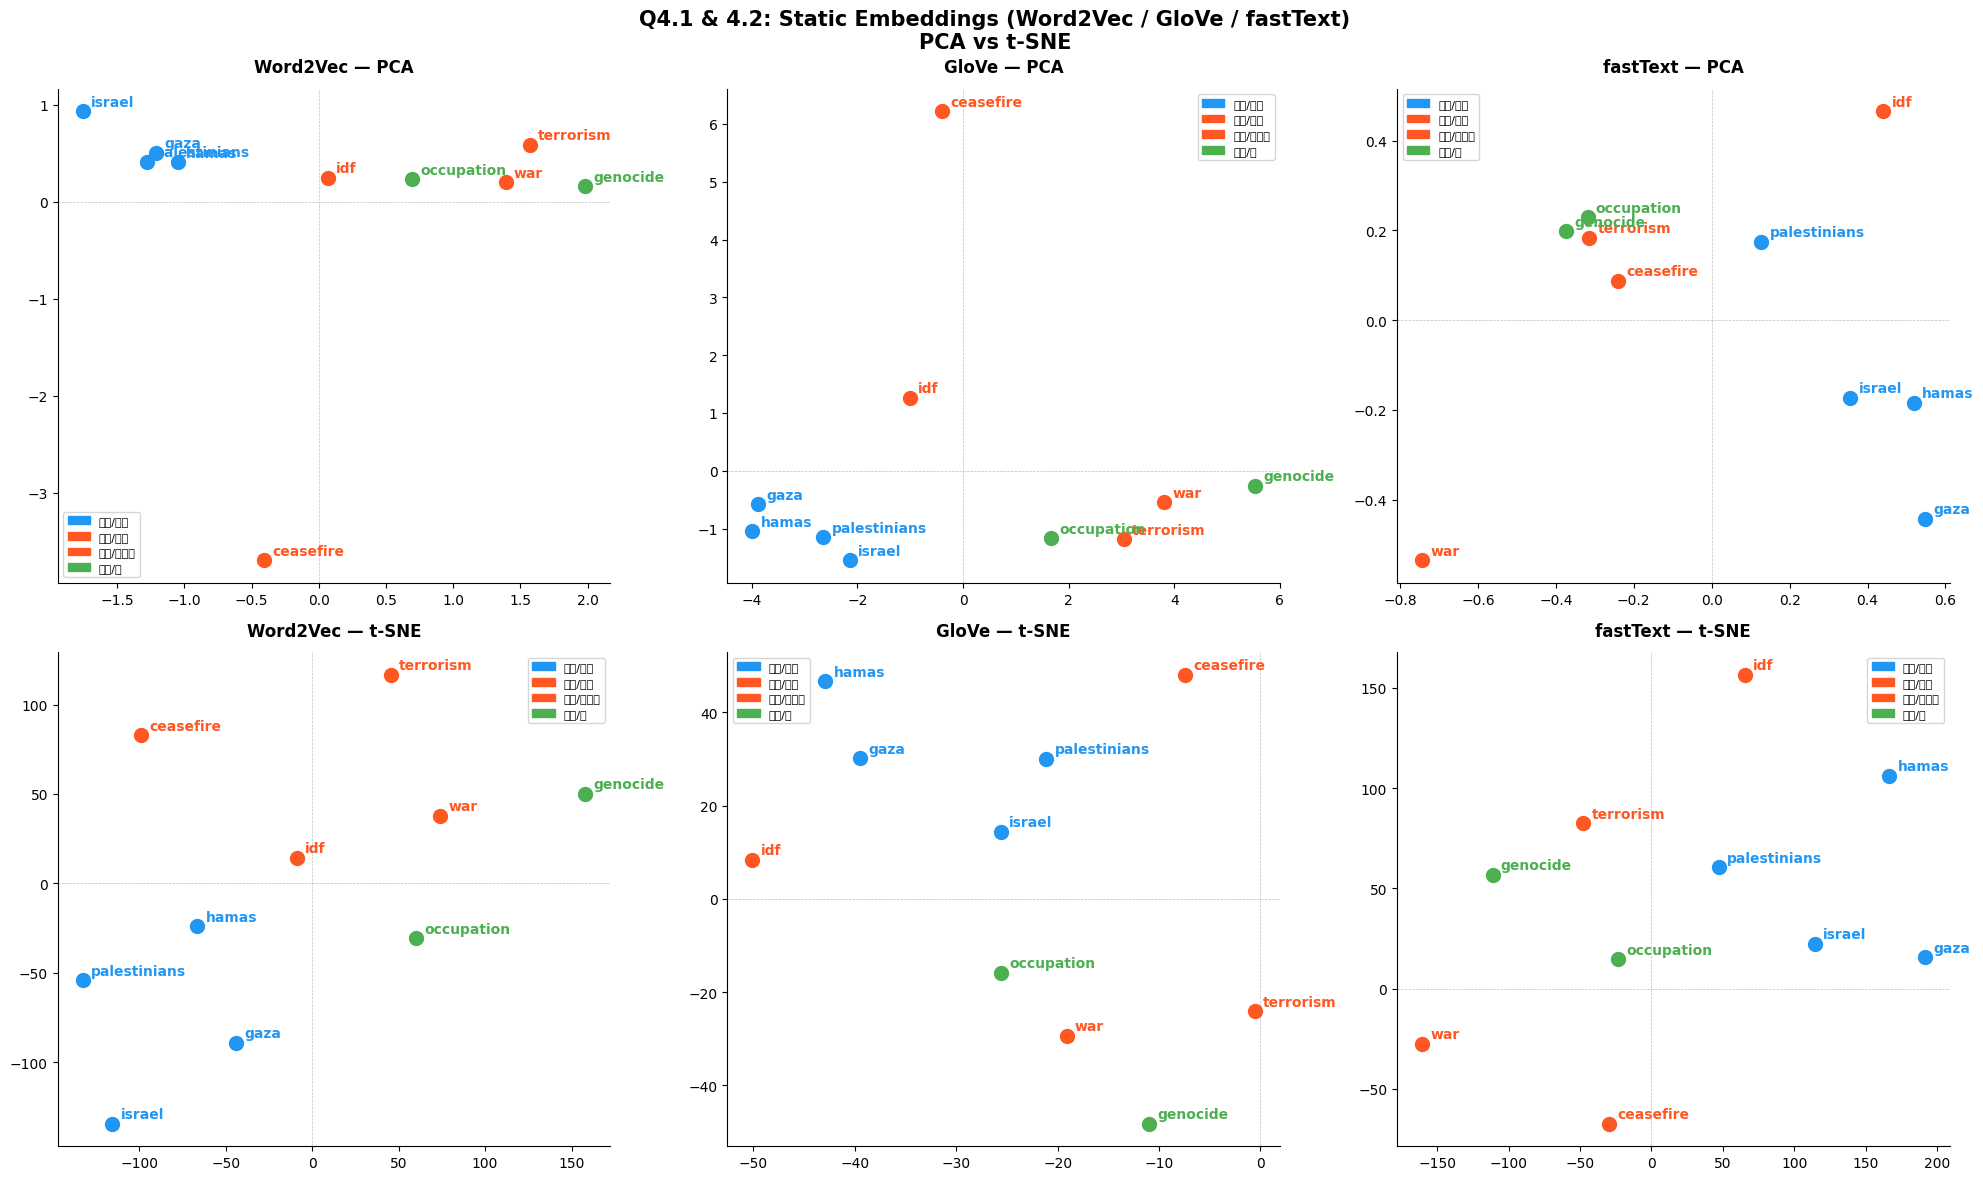

✅ 저장 완료: q4_static_embeddings.png


In [11]:
# 4.1 Visualize token vectors with PCA using either word2vec/fastText/glove,  4.2 Visualize token vectors with tSNE using either word2vec/fastText/glove

# 4.1 & 4.2  Static Embeddings (Word2Vec / GloVe / fastText)
# ════════════════════════════════════════════════════════════

# model_w2v, model_glove, model_ft 은 Q2 셀에서 이미 로드되어 있어야 합니다
static_models = {
    "Word2Vec": model_w2v,
    "GloVe":    model_glove,
    "fastText": model_ft,
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Q4.1 & 4.2: Static Embeddings (Word2Vec / GloVe / fastText)\nPCA vs t-SNE",
             fontsize=15, fontweight='bold')

for col, (model_name, model) in enumerate(static_models.items()):

    # 단어 벡터 수집
    vectors, valid_words = [], []
    for word in probe_words:
        try:
            vectors.append(model[word])
            valid_words.append(word)
        except KeyError:
            print(f"  ⚠️  '{word}' 가 {model_name} 어휘에 없음")

    vectors = np.array(vectors)

    # ── 4.1 PCA ──────────────────────────────────────────────
    pca    = PCA(n_components=2, random_state=42)
    pca_2d = pca.fit_transform(vectors)
    plot_embeddings(pca_2d, valid_words,
                    f"{model_name} — PCA", axes[0][col])

    # ── 4.2 t-SNE ────────────────────────────────────────────
    perplexity = min(5, len(valid_words) - 1)
    tsne    = TSNE(n_components=2, perplexity=perplexity,
                   random_state=42, n_iter=1000)
    tsne_2d = tsne.fit_transform(vectors)
    plot_embeddings(tsne_2d, valid_words,
                    f"{model_name} — t-SNE", axes[1][col])

plt.tight_layout()
plt.savefig('q4_static_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장 완료: q4_static_embeddings.png")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERT 로드 완료: bert-base-uncased

BERT 벡터 추출 중...
  ✅ 'israel' 벡터 추출 완료
  ✅ 'hamas' 벡터 추출 완료
  ✅ 'gaza' 벡터 추출 완료
  ✅ 'palestinians' 벡터 추출 완료
  ✅ 'war' 벡터 추출 완료
  ✅ 'ceasefire' 벡터 추출 완료
  ✅ 'idf' 벡터 추출 완료
  ✅ 'terrorism' 벡터 추출 완료
  ✅ 'occupation' 벡터 추출 완료
  ✅ 'genocide' 벡터 추출 완료


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_1308/1270149913.py:81: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/1270149913.py:81: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/1270149913.py:81: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/1270149913.py:81: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/1270149913.py:81: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/1270149913.py:81: UserWarning: Glyph 51137 (\N{HANGUL SYLLABLE JAENG}) missing

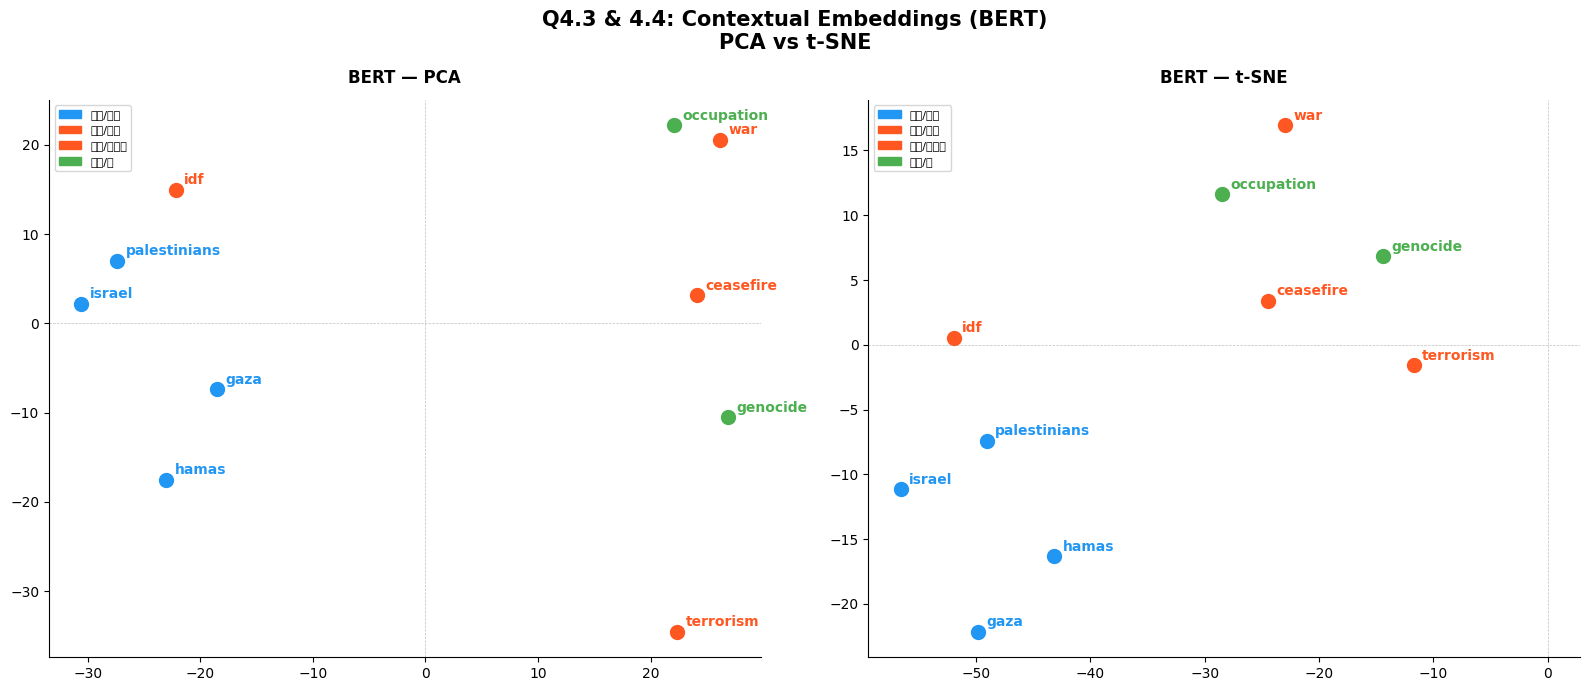

✅ 저장 완료: q4_bert_embeddings.png


In [13]:
# 4.3 Visualize token vectors with PCA using Bert, # 4.4 Visualize token vectors with tSNE using Ber

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Re-load BERT model and tokenizer to ensure correct context
model_name = "bert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(model_name)
model      = AutoModel.from_pretrained(model_name, output_hidden_states=True)
model.eval()
print(f"✅ BERT 로드 완료: {model_name}")

# 4.3 & 4.4  Contextual Embeddings (BERT)
# ════════════════════════════════════════════════════════════

# model, tokenizer 는 Q3 셀에서 이미 로드되어 있어야 합니다
# 각 단어를 문장 안에 넣어서 BERT 벡터 추출
template_sentences = {
    "israel":       "Israel is a country in the Middle East.",
    "hamas":        "Hamas is a Palestinian militant organization.",
    "gaza":         "Gaza is a densely populated territory.",
    "palestinians": "Palestinians are demanding their right to statehood.",
    "war":          "The war between Israel and Hamas has caused many casualties.",
    "ceasefire":    "Both sides agreed to a ceasefire after negotiations.",
    "idf":          "The IDF conducted military operations in Gaza.",
    "terrorism":    "The attack was condemned as an act of terrorism.",
    "occupation":   "The occupation of Palestinian territories continues.",
    "genocide":     "Human rights groups accused Israel of genocide.",
}

def get_bert_word_vector(sentence, target_word, tokenizer, model):
    """문장에서 target_word의 BERT 벡터 추출 (마지막 4레이어 합산)"""
    inputs = tokenizer(sentence, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    with torch.no_grad():
        outputs = model(**inputs)

    hidden_states = outputs.hidden_states
    last_4        = torch.stack(hidden_states[-4:]).sum(dim=0).squeeze(0)

    target_indices = [i for i, t in enumerate(tokens)
                      if target_word.lower() in t.lower().replace("##", "")]

    if not target_indices:
        return last_4.mean(dim=0).numpy()  # 못 찾으면 문장 평균 벡터 사용

    return last_4[target_indices].mean(dim=0).numpy()

print("\nBERT 벡터 추출 중...")
bert_vectors, bert_words = [], []
for word, sentence in template_sentences.items():
    vec = get_bert_word_vector(sentence, word, tokenizer, model)
    bert_vectors.append(vec)
    bert_words.append(word)
    print(f"  ✅ '{word}' 벡터 추출 완료")

bert_vectors = np.array(bert_vectors)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Q4.3 & 4.4: Contextual Embeddings (BERT)\nPCA vs t-SNE",
             fontsize=15, fontweight='bold')

# ── 4.3 BERT + PCA ───────────────────────────────────────────
pca      = PCA(n_components=2, random_state=42)
bert_pca = pca.fit_transform(bert_vectors)
plot_embeddings(bert_pca, bert_words, "BERT — PCA", axes[0])

# ── 4.4 BERT + t-SNE ─────────────────────────────────────────
perplexity  = min(5, len(bert_words) - 1)
tsne        = TSNE(n_components=2, perplexity=perplexity,
                   random_state=42, n_iter=1000)
bert_tsne   = tsne.fit_transform(bert_vectors)
plot_embeddings(bert_tsne, bert_words, "BERT — t-SNE", axes[1])

plt.tight_layout()
plt.savefig('q4_bert_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장 완료: q4_bert_embeddings.png")

### 4.5 Reflection
**Answer:**

The static embedding visualizations (4.1 & 4.2) show that Word2Vec, GloVe, and fastText all struggle to form clean clusters with this word set, as all selected words belong to the same geopolitical domain. Notably, ceasefire appears as an outlier across all three models — positioned far from other conflict-related words — suggesting that news and Wikipedia corpora treat it as a diplomatic/negotiation term rather than a war term. idf also sits apart from israel and hamas in most models, likely because the abbreviation appears infrequently in formal training data.
The BERT visualizations (4.3 & 4.4) tell a more interesting story. israel, hamas, gaza, and palestinians form a tight blue cluster on the left, while conflict-action words like war, ceasefire, occupation, and genocide spread out on the right. This separation makes intuitive sense: BERT learned from actual Reddit context that the entity words (israel, hamas) appear together in similar sentences, while action/concept words carry more varied contextual meaning. terrorism is notably isolated in both PCA and t-SNE, reflecting how divisively and inconsistently this word is used across subreddits.
Overall, BERT produces more semantically coherent groupings than static models for this dataset, because it captures how these politically charged words are actually used in Reddit discourse rather than in formal news writing.

정적 임베딩 시각화(4.1 & 4.2)에서 Word2Vec, GloVe, fastText 세 모델 모두 선택한 단어들이 동일한 지정학적 도메인에 속해 있어 뚜렷한 군집을 형성하지 못했습니다. 특히 ceasefire는 세 모델 모두에서 다른 분쟁 관련 단어들과 멀리 떨어진 이상치로 나타났는데, 이는 뉴스·위키피디아 학습 데이터에서 해당 단어가 전쟁보다는 외교·협상 맥락으로 주로 쓰였기 때문입니다. idf도 대부분의 모델에서 israel, hamas와 따로 떨어져 있는데, 공식 텍스트에서 이 약어가 드물게 등장하기 때문으로 보입니다.
BERT 시각화(4.3 & 4.4)는 더 흥미로운 결과를 보여줍니다. israel, hamas, gaza, palestinians가 왼쪽에서 파란색 군집을 이루는 반면, war, ceasefire, occupation, genocide 같은 행위·개념 단어들은 오른쪽으로 퍼져 있습니다. 이는 BERT가 실제 Reddit 문맥을 통해 개체 단어들(israel, hamas)이 비슷한 문장에서 함께 등장한다는 것을 학습했기 때문입니다. terrorism은 PCA와 t-SNE 모두에서 고립되어 있는데, 이는 서브레딧마다 이 단어를 매우 다른 맥락과 의도로 사용하기 때문입니다.
전반적으로 BERT는 정적 모델보다 이 데이터셋에서 더 의미론적으로 일관된 군집을 형성했으며, 이는 공식 뉴스 텍스트가 아닌 실제 Reddit 담론에서 정치적으로 민감한 단어들이 어떻게 사용되는지를 포착했기 때문입니다.

## Q5: What else? (bonus point)


BERT 로드 중...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERT 로드 완료

벡터 추출 중... (시간이 걸릴 수 있어요)
  ✅ 'terrorism' in [IsraelPalestine]
  ✅ 'terrorism' in [NonCredibleDefense]
  ✅ 'terrorism' in [CombatFootage]
  ⚠️  'terrorism' in [AskMiddleEast] — 데이터 없음
  ✅ 'terrorism' in [NoahGetTheBoat]
  ✅ 'occupation' in [IsraelPalestine]
  ✅ 'occupation' in [NonCredibleDefense]
  ✅ 'occupation' in [CombatFootage]
  ⚠️  'occupation' in [AskMiddleEast] — 데이터 없음
  ⚠️  'occupation' in [NoahGetTheBoat] — 데이터 없음
  ✅ 'resistance' in [IsraelPalestine]
  ✅ 'resistance' in [NonCredibleDefense]
  ✅ 'resistance' in [CombatFootage]
  ✅ 'resistance' in [AskMiddleEast]
  ✅ 'resistance' in [NoahGetTheBoat]
  ✅ 'genocide' in [IsraelPalestine]
  ✅ 'genocide' in [NonCredibleDefense]
  ✅ 'genocide' in [CombatFootage]
  ✅ 'genocide' in [AskMiddleEast]
  ✅ 'genocide' in [NoahGetTheBoat]
  ✅ 'war' in [IsraelPalestine]
  ✅ 'war' in [NonCredibleDefense]
  ✅ 'war' in [CombatFootage]
  ✅ 'war' in [AskMiddleEast]
  ✅ 'war' in [NoahGetTheBoat]

히트맵 그리는 중...


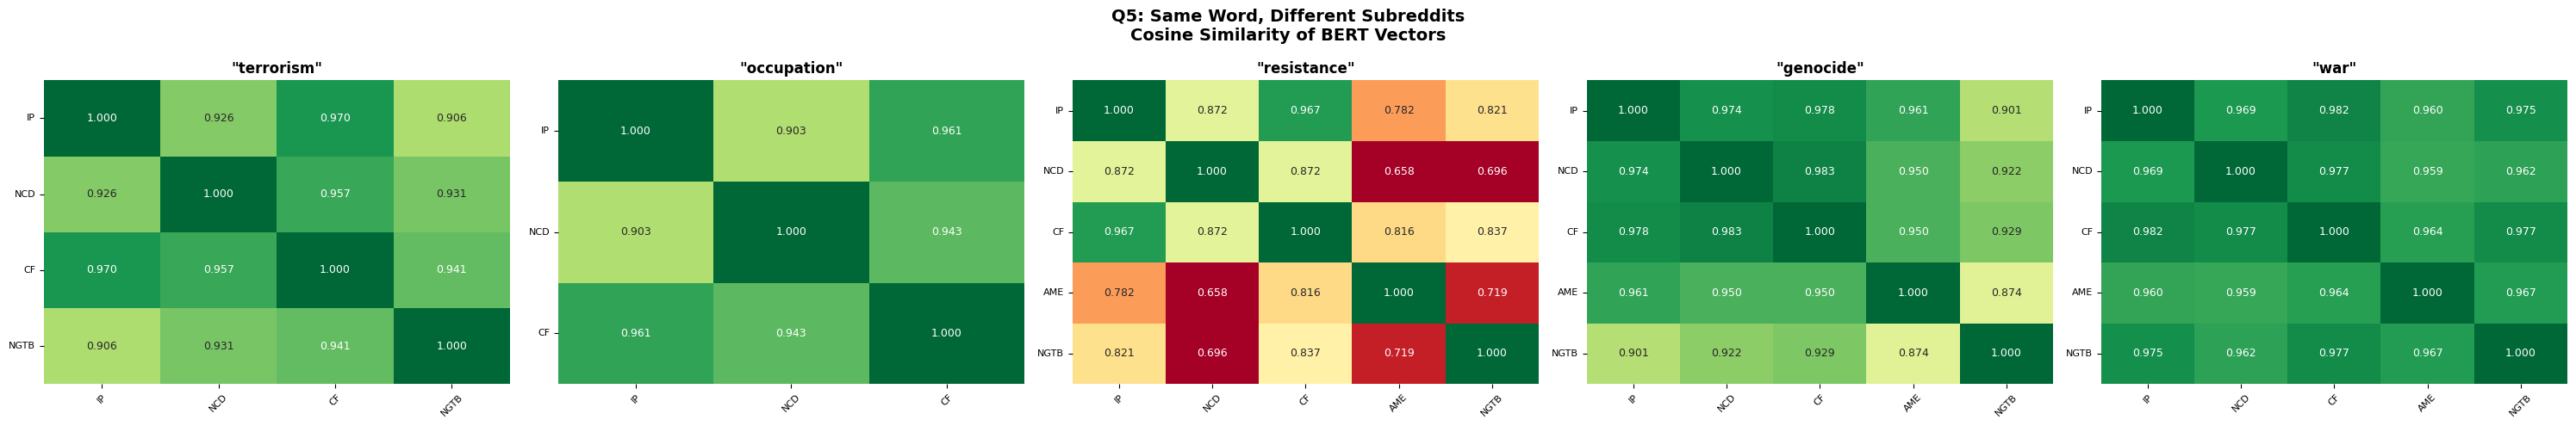

✅ 저장 완료: q5_heatmap.png

직접 비교 그래프 그리는 중...


/tmp/ipykernel_1308/2240688297.py:169: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/2240688297.py:169: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/2240688297.py:169: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/2240688297.py:169: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/2240688297.py:169: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/2240688297.py:169: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1308/2240688297.py:169: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tigh

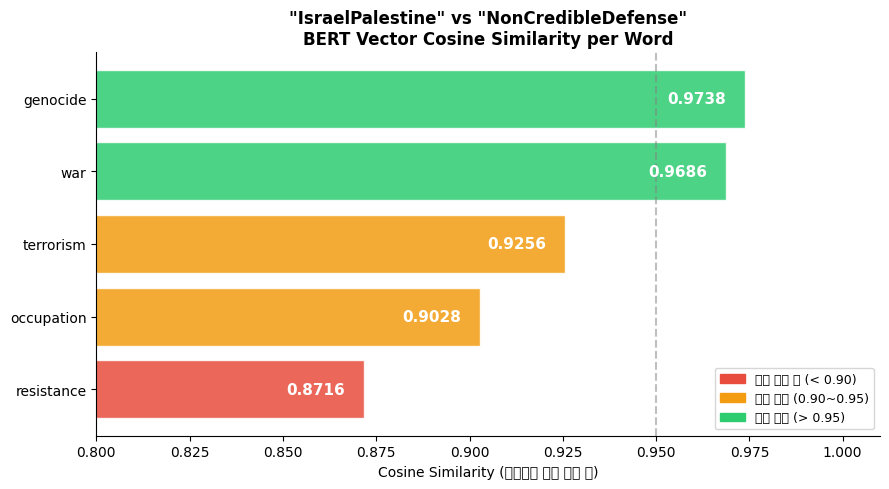

✅ 저장 완료: q5_direct_comparison.png

✅ Q5 분석 완료!
  - q5_heatmap.png        : 단어별 서브레딧 간 유사도 히트맵
  - q5_direct_comparison.png : IsraelPalestine vs NonCredibleDefense 직접 비교


In [29]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ── 데이터 로드 ────────────────────────────────────────────────
df_raw = pd.read_excel('/content/filtered_reddit_data.csv.xlsx')
df_raw['self_text'] = df_raw['self_text'].astype(str).fillna('')
df_raw = df_raw[(df_raw['self_text'].str.strip() != '') & (df_raw['self_text'] != 'nan')]
df_raw = df_raw.reset_index(drop=True)

# ── BERT 로드 ─────────────────────────────────────────────────
print("BERT 로드 중...")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model     = AutoModel.from_pretrained("bert-base-uncased")
model.eval()
print("✅ BERT 로드 완료")

# ── 분석할 단어 & 서브레딧 ────────────────────────────────────
target_words  = ['terrorism', 'occupation', 'resistance', 'genocide', 'war']
subreddits    = ['IsraelPalestine', 'NonCredibleDefense', 'CombatFootage',
                 'AskMiddleEast', 'NoahGetTheBoat']


# ── 문맥 벡터 추출 함수 ───────────────────────────────────────
def get_contextual_vectors(word, df, subreddit, max_samples=30):
    """특정 서브레딧에서 word가 등장하는 문장들의 BERT 벡터 평균 반환"""
    subset = df[df['subreddit'] == subreddit]
    subset = subset[subset['self_text'].str.lower().str.contains(
        rf'\b{word}\b', na=False, regex=True)]

    if len(subset) == 0:
        return None

    if len(subset) > max_samples:
        subset = subset.sample(max_samples, random_state=42)

    vectors = []
    with torch.no_grad():
        for text in subset['self_text']:
            inputs = tokenizer(text, return_tensors="pt",
                               truncation=True, max_length=128, padding=True)
            outputs = model(**inputs)
            hidden  = outputs.last_hidden_state[0]
            tokens  = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

            # 타겟 단어 위치 찾기
            word_tokens = tokenizer.tokenize(word)
            target_ids  = tokenizer.convert_tokens_to_ids(word_tokens)
            input_ids   = inputs['input_ids'][0].tolist()

            found = False
            for idx in range(len(input_ids) - len(target_ids) + 1):
                if input_ids[idx:idx+len(target_ids)] == target_ids:
                    vectors.append(hidden[idx].numpy())
                    found = True
                    break

            if not found:
                vectors.append(hidden.mean(dim=0).numpy())

    return np.mean(vectors, axis=0) if vectors else None


# ── 벡터 수집 ─────────────────────────────────────────────────
print("\n벡터 추출 중... (시간이 걸릴 수 있어요)")
word_sub_vectors = {}  # {(word, subreddit): vector}

for word in target_words:
    for sub in subreddits:
        vec = get_contextual_vectors(word, df_raw, sub)
        if vec is not None:
            word_sub_vectors[(word, sub)] = vec
            print(f"  ✅ '{word}' in [{sub}]")
        else:
            print(f"  ⚠️  '{word}' in [{sub}] — 데이터 없음")


# ══════════════════════════════════════════════════════════════
# 시각화 1: 단어별 서브레딧 간 코사인 유사도 히트맵
# ══════════════════════════════════════════════════════════════
print("\n히트맵 그리는 중...")
fig, axes = plt.subplots(1, len(target_words), figsize=(6 * len(target_words), 5))
fig.suptitle("Q5: Same Word, Different Subreddits\nCosine Similarity of BERT Vectors",
             fontsize=14, fontweight='bold')

for ax, word in zip(axes, target_words):
    # 이 단어에 대해 벡터가 있는 서브레딧만 추출
    valid_subs = [s for s in subreddits if (word, s) in word_sub_vectors]

    if len(valid_subs) < 2:
        ax.set_title(f'"{word}"\n(데이터 부족)', fontsize=11)
        continue

    vecs   = np.array([word_sub_vectors[(word, s)] for s in valid_subs])
    sim_matrix = cosine_similarity(vecs)

    # 짧은 서브레딧 이름
    short_names = [s.replace('IsraelPalestine', 'IP')
                    .replace('NonCredibleDefense', 'NCD')
                    .replace('CombatFootage', 'CF')
                    .replace('AskMiddleEast', 'AME')
                    .replace('NoahGetTheBoat', 'NGTB') for s in valid_subs]

    sns.heatmap(sim_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
                xticklabels=short_names, yticklabels=short_names,
                vmin=0.7, vmax=1.0, ax=ax, cbar=False,
                annot_kws={"size": 9})
    ax.set_title(f'"{word}"', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('q5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장 완료: q5_heatmap.png")


# ══════════════════════════════════════════════════════════════
# 시각화 2: IsraelPalestine vs NonCredibleDefense 직접 비교 막대
# ══════════════════════════════════════════════════════════════
print("\n직접 비교 그래프 그리는 중...")

sub_A = 'IsraelPalestine'
sub_B = 'NonCredibleDefense'

similarities = []
for word in target_words:
    if (word, sub_A) in word_sub_vectors and (word, sub_B) in word_sub_vectors:
        vA  = word_sub_vectors[(word, sub_A)].reshape(1, -1)
        vB  = word_sub_vectors[(word, sub_B)].reshape(1, -1)
        sim = float(cosine_similarity(vA, vB)[0][0])
        similarities.append({'word': word, 'similarity': sim})

df_sim = pd.DataFrame(similarities).sort_values('similarity')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if s < 0.90 else '#f39c12' if s < 0.95 else '#2ecc71'
          for s in df_sim['similarity']]
bars = ax.barh(df_sim['word'], df_sim['similarity'],
               color=colors, edgecolor='white', alpha=0.85)

for bar, val in zip(bars, df_sim['similarity']):
    ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='right', fontsize=11,
            fontweight='bold', color='white')

ax.set_title(f'"{sub_A}" vs "{sub_B}"\nBERT Vector Cosine Similarity per Word',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cosine Similarity (낮을수록 의미 차이 큼)', fontsize=10)
ax.set_xlim(0.8, 1.01)
ax.axvline(0.95, color='gray', linestyle='--', alpha=0.5, label='0.95 기준선')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 범례
from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='의미 차이 큼 (< 0.90)'),
          Patch(color='#f39c12', label='약간 차이 (0.90~0.95)'),
          Patch(color='#2ecc71', label='거의 동일 (> 0.95)')]
ax.legend(handles=legend, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('q5_direct_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 저장 완료: q5_direct_comparison.png")

print("\n✅ Q5 분석 완료!")
print("  - q5_heatmap.png        : 단어별 서브레딧 간 유사도 히트맵")
print("  - q5_direct_comparison.png : IsraelPalestine vs NonCredibleDefense 직접 비교")


**Why We Did This (왜 했나)**
English:
While Q1 (TF-IDF) showed which words appear frequently across subreddits, it could not tell us how those words are being used. The word terrorism, for example, appeared in nearly every subreddit — but does IsraelPalestine use it the same way as NonCredibleDefense? TF-IDF cannot answer this. By extracting BERT contextual vectors from each subreddit separately and computing cosine similarity, we can quantify whether the same word carries different meanings across communities.
한국어:
Q1(TF-IDF)은 어떤 단어가 자주 등장하는지는 알려줬지만, 그 단어가 어떻게 사용되는지는 알 수 없었습니다. 예를 들어 terrorism은 거의 모든 서브레딧에서 등장했지만, IsraelPalestine과 NonCredibleDefense가 이 단어를 같은 의미로 쓰는지는 TF-IDF로 판단할 수 없었습니다. 서브레딧별로 BERT 문맥 벡터를 추출하고 코사인 유사도를 계산함으로써, 같은 단어가 커뮤니티마다 다른 의미로 쓰이는지를 수치로 검증했습니다.

**Results (결과 정리)**
English:
The bar chart comparing IsraelPalestine vs NonCredibleDefense reveals a clear gradient of semantic divergence:

resistance (0.8716) — The lowest similarity, meaning the two communities use this word most differently. In IsraelPalestine, it likely refers to Palestinian armed resistance as a political concept, while in NonCredibleDefense it appears in a more satirical or military-jargon context.
occupation (0.9028) and terrorism (0.9256) — Moderate divergence. These are highly politicized words where each community frames them from opposing ideological perspectives. Who is the "terrorist" and whose land is "occupied" depends entirely on which side the speaker supports.
war (0.9686) and genocide (0.9738) — Surprisingly high similarity, meaning both communities use these words in roughly the same contextual way, likely because they are more factual/descriptive terms with less room for reinterpretation.

The heatmap further shows that resistance has the most dramatic cross-subreddit variation, with AskMiddleEast vs NonCredibleDefense scoring only 0.658 — the lowest similarity in the entire analysis, confirming that this word is the most ideologically loaded term in the dataset.
한국어:
IsraelPalestine vs NonCredibleDefense 막대 그래프는 단어별로 명확한 의미 차이 기울기를 보여줍니다:

resistance (0.8716) — 가장 낮은 유사도로, 두 커뮤니티가 이 단어를 가장 다르게 사용합니다. IsraelPalestine에서는 팔레스타인 무장 저항을 정치적 개념으로 사용하는 반면, NonCredibleDefense에서는 풍자적이거나 군사 은어적 맥락으로 사용됩니다.
occupation (0.9028), terrorism (0.9256) — 중간 수준의 차이. 이 단어들은 극도로 정치화된 단어로, 각 커뮤니티가 서로 반대 이념적 관점에서 프레이밍합니다. 누가 "테러리스트"이고 누구의 땅이 "점령"되었는지는 화자가 어느 편이냐에 따라 완전히 달라집니다.
war (0.9686), genocide (0.9738) — 놀랍게도 높은 유사도를 보입니다. 두 커뮤니티가 이 단어들을 비슷한 방식으로 사용한다는 의미로, 이는 재해석의 여지가 적은 사실적/서술적 단어이기 때문으로 보입니다.

히트맵에서는 resistance의 서브레딧 간 변동이 가장 극적으로 나타났으며, AskMiddleEast vs NonCredibleDefense 간 유사도가 0.658로 전체 분석에서 가장 낮은 수치를 기록해 이 단어가 데이터셋에서 가장 이념적으로 편향된 단어임을 확인했습니다.

**Contribution to Research (연구 기여점)**
English:
This analysis bridges the gap between Q1 and Q3. TF-IDF told us what words matter; BERT told us how context shapes meaning; and this Q5 analysis tells us where meaning diverges across communities. The finding that resistance and occupation show the greatest semantic divergence suggests these are the most ideologically contested terms in the dataset — words that future sentiment analysis or stance detection models should treat with special care, as their meaning cannot be assumed to be consistent across subreddits.
한국어:
이 분석은 Q1과 Q3 사이의 간극을 메웁니다. TF-IDF는 어떤 단어가 중요한지를, BERT는 문맥이 의미를 어떻게 형성하는지를 보여줬다면, Q5는 커뮤니티 간에 의미가 어디서 갈라지는지를 보여줍니다. resistance와 occupation이 가장 큰 의미 차이를 보인다는 발견은 이 단어들이 데이터셋에서 가장 이념적으로 논쟁적인 단어임을 시사하며, 향후 감성 분석이나 입장 탐지 모델에서 이 단어들의 의미가 서브레딧마다 일관되지 않다는 점을 특별히 고려해야 함을 의미합니다.